<a href="https://colab.research.google.com/github/AnnaZapototska/colab-code-work/blob/development/hw_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1

## Homework for the module "Learning Algorithms with a Teacher Part 1"

## Part 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

## Part 2

In [ ]:
california_housing = fetch_california_housing(as_frame=True)

data = california_housing["frame"]
# print(data.head())
# data.shape
# data.info()
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Part 3

### Part 3.1

In [ ]:
columns = ["AveRooms", "AveBedrms", "AveOccup", "Population"]

z_scores = data[columns].apply(zscore)

outliers = (z_scores.abs() > 3)
mask = outliers.any(axis=1)

outlier_indexes = data[mask].index
data_clean = data.drop(outlier_indexes)

print("Before:", data.shape)
print("After:", data_clean.shape)
print("Removed rows:", data.shape[0] - data_clean.shape[0])

Before: (20640, 9)
After: (20135, 9)
Removed rows: 505


### Part 3.2

A correlation of 0.85 is a very high correlation between `AveRooms` and `AveBedrms`, according to the heatmap from the lecture.

AveRooms is a more general characteristic of a dwelling.
AveBedrms is highly dependent on the number of rooms.

We decided in this homework to remove `AveBedrms`.

In [ ]:
data_clean = data_clean.drop(columns=["AveBedrms"])
print(data_clean.columns)

Index(['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude',
       'Longitude', 'MedHouseVal'],
      dtype='object')


## Part 4

In [ ]:
data_x = data_clean.drop(columns=["MedHouseVal"])
data_y = data_clean["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.2,random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (16108, 7)
X_test: (4027, 7)
y_train: (16108,)
y_test: (4027,)


## Part 5

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Part 6

In [ ]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)

LinearRegression()

## Part 7

In [ ]:
y_pred = model.predict(X_test_scaled)

r_sq_upd = model.score(X_test_scaled, y_test)

mae_upd = mean_absolute_error(y_test, y_pred)

mape_upd = mean_absolute_percentage_error(y_test, y_pred)

print(f"R²: {r_sq_upd:.2f} | MAE: {mae_upd:.2f} | MAPE: {mape_upd:.2f}")

R²: 0.65 | MAE: 0.51 | MAPE: 0.30


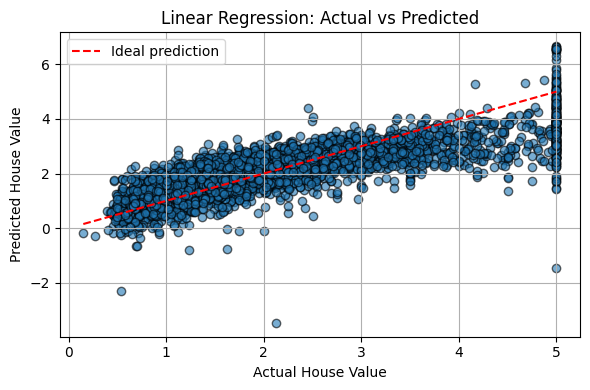

In [ ]:
plt.figure(figsize=(6, 4))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6,
    edgecolors="k"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    label="Ideal prediction"
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()

plt.grid(True)
plt.tight_layout()

plt.show()

## Part 8

## Summary

After cleaning the data from outliers, removing one of the highly correlated features, and training a linear regression model, the following results were obtained:
R² = 0.65
MAE = 0.51
MAPE = 0.30

The results obtained indicate that linear regression provides satisfactory quality of housing price forecasting, but is not able to fully describe all dependencies in the data. The value of R² = 0.65 confirms that the model explains most of the variation of the target variable, but there is still room for improvement.

The average relative error of the model is about 30%, that is, the predicted price differs from the actual price by about a third on average.